In [1]:
# CELL 1 - Import Libraries & Configurations
import os
import time
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor as cat
from prophet import Prophet
import shap
from sklearn.linear_model import HuberRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from datetime import datetime, timedelta

# Cấu hình hiển thị và hệ thống
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)

SEED = 42
seed_everything(SEED)
TRAIN_START = '2012-07-04'
TRAIN_END   = '2022-12-31'
TEST_START  = '2023-01-01'
TEST_END    = '2024-07-01'

DATA_DIR = "/kaggle/input/competitions/datathon-2026-round-1/"
OUT_FILE = 'submission.csv'

# Cấu hình Walking Foward Fold

WF_FOLDS = [
    ('2012-07-04', '2018-12-31', '2019-01-01', '2019-12-31'),
    ('2012-07-04', '2019-12-31', '2020-01-01', '2020-12-31'),
    ('2012-07-04', '2020-12-31', '2021-01-01', '2021-12-31'),
    ('2012-07-04', '2021-12-31', '2022-01-01', '2022-12-31')
]

print(f"Hệ thống đã sẵn sàng. Giai đoạn huấn luyện: {TRAIN_START} đến {TRAIN_END}")
print(f"Giai đoạn dự báo (Kaggle Test): {TEST_START} đến {TEST_END}")

Hệ thống đã sẵn sàng. Giai đoạn huấn luyện: 2012-07-04 đến 2022-12-31
Giai đoạn dự báo (Kaggle Test): 2023-01-01 đến 2024-07-01


In [2]:
# Cell 2 - Load Data

# Downcast dữ liệu
def downcast_df(df):
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns

    fcols = [c for c in fcols if c not in ['Revenue', 'COGS']]

    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')
    return df

# Tạo list các bảng
file_names = [
    'products', 'customers', 'promotions', 'geography',
    'orders', 'order_items', 'payments', 'shipments',
    'returns', 'reviews', 'sales', 'inventory',
    'web_traffic', 'sample_submission'
]

data = {}
for file in file_names:
    path = f"{DATA_DIR}{file}.csv"
    if os.path.exists(path):
        temp_df = pd.read_csv(path)
        date_cols = [c for c in temp_df.columns if 'date' in c.lower()]

        df = pd.read_csv(path, parse_dates=date_cols)
        data[file] = downcast_df(df)
        print(f"Loaded {file:<18} | Memory: {df.memory_usage().sum()/1e6:.2f} MB")

Loaded products           | Memory: 0.14 MB
Loaded customers          | Memory: 5.85 MB
Loaded promotions         | Memory: 0.00 MB
Loaded geography          | Memory: 1.12 MB
Loaded orders             | Memory: 33.64 MB
Loaded order_items        | Memory: 27.87 MB
Loaded payments           | Memory: 13.59 MB
Loaded shipments          | Memory: 13.59 MB
Loaded returns            | Memory: 1.56 MB
Loaded reviews            | Memory: 3.97 MB
Loaded sales              | Memory: 0.09 MB
Loaded inventory          | Memory: 3.55 MB
Loaded web_traffic        | Memory: 0.13 MB
Loaded sample_submission  | Memory: 0.01 MB


In [3]:
# CELL 3 - Tạo Master DataFrame & Timeline

sales = data['sales'].copy()

test_dates = pd.date_range(start=TEST_START, end=TEST_END, freq='D')
sales_test = pd.DataFrame({'Date': test_dates})

# Khởi tạo giá trị trống cho tập Test
sales_test['Revenue'] = np.nan
sales_test['COGS']    = np.nan

# Tạo Master_DF làm backbone của toàn bộ Pipeline
df_master = pd.concat([sales, sales_test], axis=0).reset_index(drop=True)

# Sort theo thời gian
df_master = df_master.sort_values('Date').reset_index(drop=True)

# Kiểm tra dữ liệu
print(f"Kích thước Master_DF: {df_master.shape}")
print(f"Khoảng thời gian: {df_master['Date'].min()} -> {df_master['Date'].max()}")
print(f"Số dòng tập Train: {len(sales)}")
print(f"Số dòng tập Test: {len(sales_test)}")

# Hiển thị điểm giao giữa dữ liệu huấn luyện và dữ liệu dự báo
display(df_master[(df_master['Date'] >= '2022-12-28') & (df_master['Date'] <= '2023-01-03')])

Kích thước Master_DF: (4381, 3)
Khoảng thời gian: 2012-07-04 00:00:00 -> 2024-07-01 00:00:00
Số dòng tập Train: 3833
Số dòng tập Test: 548


,Date,Revenue,COGS
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13
3833,2023-01-01,NaN,NaN
3834,2023-01-02,NaN,NaN
3835,2023-01-03,NaN,NaN


In [4]:
# CELL 4 - Merge Data

# Các bảng master
products = data['products'].copy()
promotions = data['promotions'].copy()

# Promotions
# Chuyển đổi ngày tháng để map vào trục thời gian
promotions['start_date'] = pd.to_datetime(promotions['start_date'])
promotions['end_date'] = pd.to_datetime(promotions['end_date'])

# Mean của rev và cogs theo category
avg_price_by_cat = products.groupby('category')['price'].mean().to_dict()
avg_cogs_by_cat = products.groupby('category')['cogs'].mean().to_dict()

# Hai bảng này giữ lại để trích xuất Macro-Lags
operational_tables = ['web_traffic', 'inventory']

# Kiểm tra các bảng
print(f"\nSố lượng chiến dịch khuyến mãi: {len(promotions)}")
print(f"Số lượng danh mục sản phẩm: {products['category'].nunique()}")


Số lượng chiến dịch khuyến mãi: 50
Số lượng danh mục sản phẩm: 4


In [5]:
# CELL 5 - Lịch âm & Hành vi thanh toán

# Khai báo các ngày Mùng 1 Tết từ 2012 đến 2025
tet_dates_list = [
    '2012-01-23', '2013-02-10', '2014-01-31', '2015-02-19',
    '2016-02-08', '2017-01-28', '2018-02-16', '2019-02-05',
    '2020-01-25', '2021-02-12', '2022-02-01', '2023-01-22',
    '2024-02-10', '2025-01-29'
]
tet_dates = pd.to_datetime(tet_dates_list)

# Tính khoảng cách đến ngày Tết gần nhất
def get_tet_distance(current_date):
    # Tính khoảng cách từ ngày hiện tại đến các ngày Tết
    distances = (current_date - tet_dates).days
    # Tìm khoảng cách nhỏ nhất (ngày Tết gần nhất)
    closest_idx = abs(distances).argmin()
    return distances[closest_idx]

# Áp dụng hàm tính khoảng cách Tết
df_master['days_from_tet'] = df_master['Date'].apply(get_tet_distance)

# Tạo biến đếm ngược/đếm xuôi (+- 21 ngày)
df_master['days_to_tet'] = df_master['days_from_tet'].apply(lambda x: abs(x) if -21 <= x <= 0 else 0)
df_master['days_after_tet'] = df_master['days_from_tet'].apply(lambda x: x if 0 < x <= 21 else 0)

# Tạo biến is_tet_holiday (Từ 30 Tết đến Mùng 3 Tết)
df_master['is_tet_holiday'] = df_master['days_from_tet'].apply(lambda x: 1 if -1 <= x <= 3 else 0)

# Payday Window: Mùng 5, 10, 15, cuối tháng +- 2 ngày
def is_payday_window(date):
    day = date.day
    days_in_month = date.days_in_month
    paydays = [5, 10, 15, days_in_month]
    
    for pd_day in paydays:
        if abs(day - pd_day) <= 2:
            return 1
    return 0

df_master['is_payday_window'] = df_master['Date'].apply(is_payday_window)

print("Hoàn tất nhúng Lịch Tết và Payday.")

Hoàn tất nhúng Lịch Tết và Payday.


In [6]:
# CELL 6 - Megasale & BlackFriday

# Mega Sale (Ngày Đôi: 1/1, 2/2, ..., 12/12)
df_master['is_mega_sale'] = (df_master['Date'].dt.day == df_master['Date'].dt.month).astype(int)

# Black Friday (Thứ 6 lần thứ 4 của tháng 11)
def is_black_friday(date):
    if date.month == 11 and date.dayofweek == 4: # Thứ 6
        # Kiểm tra xem đây có phải thứ 6 thứ 4 không (ngày từ 22 đến 28)
        if 22 <= date.day <= 28:
            return 1
    return 0

df_master['is_black_friday'] = df_master['Date'].apply(is_black_friday)

# Gộp chung vào Mega Sale
df_master['is_mega_sale'] = np.maximum(df_master['is_mega_sale'], df_master['is_black_friday'])

# Tính khoảng cách đến ngày Mega Sale gần nhất trong tháng (hoặc đầu tháng sau)
def days_to_next_mega_sale(date):
    # Ngày mega sale của tháng hiện tại
    mega_date_this_month = pd.Timestamp(year=date.year, month=date.month, day=date.month)

    if date <= mega_date_this_month:
        diff = (mega_date_this_month - date).days
    else:
        # Ngày mega sale của tháng sau
        next_month = date.month + 1 if date.month < 12 else 1
        next_year = date.year if date.month < 12 else date.year + 1
        mega_date_next_month = pd.Timestamp(year=next_year, month=next_month, day=next_month)
        diff = (mega_date_next_month - date).days

    # Chỉ bám vào tâm lý chờ sale trong vòng 7 ngày
    return diff if diff <= 7 else 0

df_master['days_to_mega_sale'] = df_master['Date'].apply(days_to_next_mega_sale)


SALE_SEASONS = [
    {'month': 1,  'start_day': 30, 'duration': 30, 'profit_rank': 1},  # Sau Tết
    {'month': 3,  'start_day': 18, 'duration': 30, 'profit_rank': 2},  # Spring sale
    {'month': 6,  'start_day': 23, 'duration': 29, 'profit_rank': 3},  # Mid-year
    {'month': 7,  'start_day': 30, 'duration': 34, 'profit_rank': 5},
    {'month': 8,  'start_day': 30, 'duration': 32, 'profit_rank': 4},
    {'month': 11, 'start_day': 18, 'duration': 45, 'profit_rank': 6},  # Black Friday
]

years = df_master['Date'].dt.year.unique()
df_master['is_sale_season']       = 0
df_master['sale_rank']            = 0
df_master['days_to_next_sale']    = 999
df_master['days_since_last_sale'] = 999

for year in years:
    for s in SALE_SEASONS:
        try:
            start = pd.Timestamp(year=year, month=s['month'], day=s['start_day'])
        except ValueError:
            start = pd.Timestamp(year=year, month=s['month'], day=1) + pd.offsets.MonthEnd(0)
        end = start + pd.Timedelta(days=s['duration'] - 1)
        rank = s['profit_rank']

        mask_in = (df_master['Date'] >= start) & (df_master['Date'] <= end)
        df_master.loc[mask_in, 'is_sale_season'] = 1
        df_master.loc[mask_in, 'sale_rank']      = rank

        mask_before = df_master['Date'] < start
        days_to = (start - df_master.loc[mask_before, 'Date']).dt.days
        df_master.loc[mask_before, 'days_to_next_sale'] = np.minimum(
            df_master.loc[mask_before, 'days_to_next_sale'], days_to
        )

        mask_after = df_master['Date'] > end
        days_since = (df_master.loc[mask_after, 'Date'] - end).dt.days
        df_master.loc[mask_after, 'days_since_last_sale'] = np.minimum(
            df_master.loc[mask_after, 'days_since_last_sale'], days_since
        )

df_master.loc[df_master['is_sale_season'] == 1, 'days_to_next_sale']    = 0
df_master.loc[df_master['is_sale_season'] == 1, 'days_since_last_sale'] = 0

print("Đã hoàn tất đánh dấu Mega Sale và Sale Season")

Đã hoàn tất đánh dấu Mega Sale và Sale Season


In [7]:
# CELL 7 - Áp lực khuyến mãi

# Trải phẳng các chiến dịch khuyến mãi theo ngày
# Tạo danh sách các ngày mà mỗi chiến dịch đang active
promotions['active_dates'] = promotions.apply(
    lambda row: pd.date_range(row['start_date'], row['end_date']), axis=1
)
promo_exploded = promotions.explode('active_dates')

# 2. Tổng hợp theo từng ngày
promo_daily = promo_exploded.groupby('active_dates').agg(
    active_promos_count    = ('promo_id',            'count'),
    max_discount_depth     = ('discount_value',       'max'),
    avg_discount_depth     = ('discount_value',       'mean'),
    sum_discount_depth     = ('discount_value',       'sum'),
    has_stackable_promo    = ('stackable_flag',       'max'),
    diverse_promo_cats     = ('applicable_category',  'nunique'),
    has_all_cat_promo      = ('applicable_category',  lambda x: x.isna().any().astype(int)),
    min_order_barrier      = ('min_order_value',      lambda x: x.dropna().min() if x.notna().any() else 0),
    pct_promo_count        = ('promo_type',           lambda x: (x == 'percentage').sum()),
    fixed_promo_count      = ('promo_type',           lambda x: (x == 'fixed').sum()),
).reset_index()

promo_daily.rename(columns={'active_dates': 'Date'}, inplace=True)

# Merge vào Master_DF
df_master = df_master.merge(promo_daily, on='Date', how='left')

# Fill NaN
fill_zero_cols = ['active_promos_count','max_discount_depth','avg_discount_depth',
                  'sum_discount_depth','has_stackable_promo','diverse_promo_cats',
                  'has_all_cat_promo','min_order_barrier','pct_promo_count','fixed_promo_count']
df_master[fill_zero_cols] = df_master[fill_zero_cols].fillna(0)

print("Đã hoàn tất tính toán Áp lực Khuyến mãi.")

Đã hoàn tất tính toán Áp lực Khuyến mãi.


In [8]:
# CELL 8 - MACRO-LAGS & ECHOES

web_traffic = data['web_traffic'].copy()
inventory = data['inventory'].copy()
# Traffic Echo (Đúng 364 ngày trước để khớp thứ trong tuần)
web_traffic = data['web_traffic'].copy()

# Tổng hợp theo ngày
web_daily = web_traffic.groupby('date').agg(
    sessions_total     = ('sessions', 'sum'),
    unique_visitors    = ('unique_visitors', 'sum'),
    page_views_total   = ('page_views', 'sum'),
    avg_bounce_rate    = ('bounce_rate', 'mean'),
    avg_duration       = ('avg_session_duration_sec', 'mean'),
).reset_index().rename(columns={'date': 'Date'})

# Tính engagement score (proxy chất lượng traffic)
web_daily['engagement_score'] = (
    web_daily['avg_duration'] * (1 - web_daily['avg_bounce_rate'])
)

# Echo 364 ngày cho TẤT CẢ các cột
echo_cols = ['sessions_total', 'unique_visitors', 'page_views_total',
             'avg_bounce_rate', 'avg_duration', 'engagement_score']

for col in echo_cols:
    echo_df = web_daily[['Date', col]].copy()
    echo_df['Date'] = echo_df['Date'] + pd.Timedelta(days=364)
    echo_df = echo_df.rename(columns={col: f'{col}_echo364'})
    df_master = df_master.merge(echo_df, on='Date', how='left')

# Rolling mean của sessions trên vùng safe (xu hướng traffic trung hạn)
web_echo = web_daily[['Date', 'sessions_total']].copy()
web_echo['Date'] = web_echo['Date'] + pd.Timedelta(days=364)
web_echo = web_echo.rename(columns={'sessions_total': 'sessions_for_roll'})
df_master = df_master.merge(web_echo, on='Date', how='left')

for w in [7, 30]:
    df_master[f'sessions_roll_mean_{w}_echo'] = (
        df_master['sessions_for_roll'].rolling(w, min_periods=1).mean()
    )
df_master.drop(columns=['sessions_for_roll'], inplace=True)

# Fill NaN
web_feature_cols = [c for c in df_master.columns if 'echo364' in c or 'sessions_roll' in c]
df_master[web_feature_cols] = df_master[web_feature_cols].fillna(0)

# Stockout Echo (Cùng kỳ tháng này năm ngoái)
inventory = data['inventory'].copy()

# Tổng hợp nhiều chỉ số theo year-month
inv_monthly = inventory.groupby(['year', 'month']).agg(
    stockout_rate     = ('stockout_flag',    'mean'),
    overstock_rate    = ('overstock_flag',   'mean'),
    reorder_rate      = ('reorder_flag',     'mean'),
    avg_fill_rate     = ('fill_rate',        'mean'),
    avg_days_supply   = ('days_of_supply',   'mean'),
    avg_sell_through  = ('sell_through_rate','mean'),
    avg_stock_on_hand = ('stock_on_hand',    'mean'),
).reset_index()

# Shift 1 năm
inv_echo = inv_monthly.copy()
inv_echo['year'] = inv_echo['year'] + 1

df_master['year']  = df_master['Date'].dt.year
df_master['month'] = df_master['Date'].dt.month

df_master = df_master.merge(inv_echo, on=['year', 'month'], how='left')

# Fill NaN
inv_cols = ['stockout_rate','overstock_rate','reorder_rate',
            'avg_fill_rate','avg_days_supply','avg_sell_through','avg_stock_on_hand']
df_master[inv_cols] = df_master[inv_cols].fillna(method='ffill').fillna(0)

print("Đã hoàn tất trích xuất")
display(df_master.tail()) # Kiểm tra phần đuôi của Test set xem đã có features chưa

Đã hoàn tất trích xuất


,Date,Revenue,COGS,days_from_tet,days_to_tet,days_after_tet,is_tet_holiday,is_payday_window,is_mega_sale,is_black_friday,...,sessions_roll_mean_30_echo,year,month,stockout_rate,overstock_rate,reorder_rate,avg_fill_rate,avg_days_supply,avg_sell_through,avg_stock_on_hand
4376,2024-06-27,NaN,NaN,138,0,0,0,0,0,0,...,0.0,2024,6,0.67217,0.804245,0.0,0.961244,1869.229492,0.118345,245.837264
4377,2024-06-28,NaN,NaN,139,0,0,0,1,0,0,...,0.0,2024,6,0.67217,0.804245,0.0,0.961244,1869.229492,0.118345,245.837264
4378,2024-06-29,NaN,NaN,140,0,0,0,1,0,0,...,0.0,2024,6,0.67217,0.804245,0.0,0.961244,1869.229492,0.118345,245.837264
4379,2024-06-30,NaN,NaN,141,0,0,0,1,0,0,...,0.0,2024,6,0.67217,0.804245,0.0,0.961244,1869.229492,0.118345,245.837264
4380,2024-07-01,NaN,NaN,142,0,0,0,0,0,0,...,0.0,2024,7,0.67217,0.804245,0.0,0.961244,1869.229492,0.118345,245.837264


In [9]:
# CELL 9 - Revenue / COGS Echo
# Echoes (shift truc tiep)
for lag in [364, 365, 366, 728, 730]:
    df_master[f'rev_lag_{lag}'] = df_master['Revenue'].shift(lag)
    df_master[f'cogs_lag_{lag}'] = df_master['COGS'].shift(lag)

# Rolling stat tren vung safe (shift 364 truoc, rolling sau)
rev_shifted = df_master['Revenue'].shift(364)
for window in [7, 14, 30, 90]:
    df_master[f'rev_roll_mean_{window}_echo'] = rev_shifted.rolling(window).mean()
    df_master[f'rev_roll_std_{window}_echo']  = rev_shifted.rolling(window).std()
    df_master[f'rev_roll_max_{window}_echo']  = rev_shifted.rolling(window).max()
    df_master[f'rev_roll_min_{window}_echo']  = rev_shifted.rolling(window).min()

df_master['rev_yoy_growth'] = (
    df_master['Revenue'].shift(364) - df_master['Revenue'].shift(728)
) / df_master['Revenue'].shift(728).replace(0, np.nan)
df_master['rev_yoy_growth'] = df_master['rev_yoy_growth'].clip(-2, 5).fillna(0)

# Fill NaN
for lag in [364, 365, 366, 728, 730]:
    df_master[f'rev_lag_{lag}'] = df_master[f'rev_lag_{lag}'].fillna(0)
    df_master[f'cogs_lag_{lag}'] = df_master[f'cogs_lag_{lag}'].fillna(0)
    
for window in [7, 14, 30, 90]:
    df_master[f'rev_roll_mean_{window}_echo'] = df_master[f'rev_roll_mean_{window}_echo'].fillna(0)
    df_master[f'rev_roll_std_{window}_echo'] = df_master[f'rev_roll_std_{window}_echo'].fillna(0)
    df_master[f'rev_roll_max_{window}_echo'] = df_master[f'rev_roll_max_{window}_echo'].fillna(0)
    df_master[f'rev_roll_min_{window}_echo'] = df_master[f'rev_roll_min_{window}_echo'].fillna(0)

df_master['rev_yoy_growth'] = df_master['rev_yoy_growth'].fillna(0)
display(df_master.tail()) # Kiểm tra phần đuôi của Test set xem đã có features chưa

,Date,Revenue,COGS,days_from_tet,days_to_tet,days_after_tet,is_tet_holiday,is_payday_window,is_mega_sale,is_black_friday,...,rev_roll_min_14_echo,rev_roll_mean_30_echo,rev_roll_std_30_echo,rev_roll_max_30_echo,rev_roll_min_30_echo,rev_roll_mean_90_echo,rev_roll_std_90_echo,rev_roll_max_90_echo,rev_roll_min_90_echo,rev_yoy_growth
4376,2024-06-27,NaN,NaN,138,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4377,2024-06-28,NaN,NaN,139,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4378,2024-06-29,NaN,NaN,140,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4379,2024-06-30,NaN,NaN,141,0,0,0,1,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4380,2024-07-01,NaN,NaN,142,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [10]:
# CELL 10 - Trích xuất feature từ các bảng khác
orders   = data['orders'].copy()
payments = data['payments'].copy()
order_items = data['order_items'].copy()

# orders
daily_orders = orders.groupby('order_date').agg(
    order_count       = ('order_id', 'count'),
    unique_customers  = ('customer_id', 'nunique'),
    cancel_rate       = ('order_status', lambda x: (x == 'cancelled').mean()),
    mobile_rate       = ('device_type',  lambda x: (x == 'mobile').mean()),
).reset_index().rename(columns={'order_date': 'Date'})

# payments
aov_daily = payments.merge(
    orders[['order_id', 'order_date']], on='order_id'
).groupby('order_date').agg(
    avg_order_value = ('payment_value', 'mean'),
    total_gmv       = ('payment_value', 'sum'),
).reset_index().rename(columns={'order_date': 'Date'})

# order_items
oi_with_date = order_items.merge(
    orders[['order_id', 'order_date']], on='order_id'
)
daily_items = oi_with_date.groupby('order_date').agg(
    total_quantity    = ('quantity', 'sum'),
    promo_attach_rate = ('promo_id', lambda x: x.notna().mean()),
    avg_discount_amt  = ('discount_amount', 'mean'),
).reset_index().rename(columns={'order_date': 'Date'})

# Merge lại
ops_daily = daily_orders \
    .merge(aov_daily,    on='Date', how='left') \
    .merge(daily_items,  on='Date', how='left')

# Echo 364 ngày cho tất cả
ops_echo_cols = ['order_count', 'unique_customers', 'cancel_rate',
                 'mobile_rate', 'avg_order_value', 'total_gmv',
                 'total_quantity', 'promo_attach_rate', 'avg_discount_amt']

for col in ops_echo_cols:
    echo_df = ops_daily[['Date', col]].copy()
    echo_df['Date'] = echo_df['Date'] + pd.Timedelta(days=364)
    echo_df = echo_df.rename(columns={col: f'{col}_echo364'})
    df_master = df_master.merge(echo_df, on='Date', how='left')

# Fill NaN
ops_feat_cols = [f'{c}_echo364' for c in ops_echo_cols]
df_master[ops_feat_cols] = df_master[ops_feat_cols].fillna(0)

In [11]:
# Cell 11 - Prophet + Residual

train_mask = df_master['Revenue'].notnull()
test_df = df_master[df_master['Revenue'].isnull()].copy()

# Chuẩn bị data cho Prophet
df_train_prophet = sales[['Date', 'Revenue']].copy()
df_train_prophet['Revenue_log'] = np.log1p(df_train_prophet['Revenue'])
df_train_prophet = df_train_prophet.rename(columns={'Date': 'ds', 'Revenue_log': 'y'})

# Train Prophet trên toàn bộ training data
final_prophet = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.15,
    seasonality_prior_scale=10.0,
    seasonality_mode='multiplicative'
)
final_prophet.fit(df_train_prophet)

# Tính residual cho tập train
train_trend = final_prophet.predict(df_train_prophet[['ds']])['yhat'].values
df_master.loc[train_mask, 'revenue_log'] = np.log1p(df_master.loc[train_mask, 'Revenue'])
df_master.loc[train_mask, 'prophet_trend'] = train_trend
df_master.loc[train_mask, 'target_residual'] = (
    df_master.loc[train_mask, 'revenue_log'] - train_trend
)

# Tính prophet trend cho tập test
test_dates_prophet = test_df[['Date']].rename(columns={'Date': 'ds'})
test_trend = final_prophet.predict(test_dates_prophet)['yhat'].values
test_df['prophet_trend'] = test_trend

# Tính COGS_Ratio
df_master.loc[train_mask, 'COGS_Ratio'] = (
    df_master.loc[train_mask, 'COGS'] /
    (df_master.loc[train_mask, 'Revenue'] + 1e-9)
)

13:32:00 - cmdstanpy - INFO - Chain [1] start processing
13:32:01 - cmdstanpy - INFO - Chain [1] done processing


In [12]:
# CELL 12 - TẠO BIẾN TƯƠNG TÁC & SÀNG LỌC ĐẶC TRƯNG

# Các biến cơ sở
df_master['is_weekend'] = df_master['Date'].dt.dayofweek.isin([5, 6]).astype(int)

# Fourier cho Month và DayOfWeek
month = df_master['Date'].dt.month
df_master['month_sin'] = np.sin(2 * np.pi * month / 12)
df_master['month_cos'] = np.cos(2 * np.pi * month / 12)

dow = df_master['Date'].dt.dayofweek
df_master['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df_master['dow_cos'] = np.cos(2 * np.pi * dow / 7)

# Mã hóa Fourier cho DayOfYear và WeekOfYear để tránh overfit
doy = df_master['Date'].dt.dayofyear
for k in [1, 2, 3]:  # 3 harmonics
    df_master[f'doy_sin_{k}'] = np.sin(2 * np.pi * k * doy / 365.25)
    df_master[f'doy_cos_{k}'] = np.cos(2 * np.pi * k * doy / 365.25)

woy = df_master['Date'].dt.isocalendar().week.astype(int)
df_master['woy_sin'] = np.sin(2 * np.pi * woy / 52)
df_master['woy_cos'] = np.cos(2 * np.pi * woy / 52)

df_master['quarter'] = df_master['Date'].dt.quarter

# Ngày lễ Việt Nam
vn_holiday_dates = {
    'liberation_day': (4, 30),
    'labor_day':      (5, 1),
    'national_day':   (9, 2),
    'new_year_solar': (1, 1),
}
for name, (m, d) in vn_holiday_dates.items():
    df_master[f'is_{name}'] = ((df_master['Date'].dt.month == m) & (df_master['Date'].dt.day == d)).astype(int)
    df_master[f'near_{name}'] = ((df_master['Date'].dt.month == m) & (df_master['Date'].dt.day.between(d-3, d+3))).astype(int)

# Tương tác: Doanh thu cùng kỳ x Xếp hạng chiến dịch
df_master['rev_lag364_x_sale_rank'] = df_master['rev_lag_364'] * df_master['sale_rank']
# Đo lường mức độ biến động
df_master['rev_volatility_echo'] = (df_master['rev_roll_std_14_echo'] / (df_master['rev_roll_mean_14_echo'] + 1e-9)).clip(0, 5)
# Cường độ Khuyến mãi tổng hợp (Breadth x Depth)
df_master['promo_breadth_depth'] = df_master['sum_discount_depth'] * df_master['diverse_promo_cats']

# Biến Seasonality
peak_months = [(4, 1), (5, 1), (11, 1)] 
def days_to_nearest_peak(date):
    year = date.year
    candidates = []
    for m, d in peak_months:
        for y in [year-1, year, year+1]:
            try:
                candidates.append(pd.Timestamp(y, m, d))
            except:
                pass
    return min(abs((date - c).days) for c in candidates)

df_master['days_to_peak'] = df_master['Date'].apply(days_to_nearest_peak)
df_master['peak_proximity'] = 1 / (1 + df_master['days_to_peak'])
df_master['is_peak_season'] = df_master['Date'].dt.month.isin([4, 5, 11]).astype(int)

# KHAI BÁO DANH SÁCH DROPS & SÀNG LỌC
# Các cột chống Data Leakage và cột thô không cần thiết
cols_to_drop = [
    'Date', 'Revenue', 'COGS', 
    'revenue_log', 'prophet_trend', 'target_residual', 'COGS_Ratio',
    'base_forecast_rev', 'base_forecast_cogs',
    'target_ratio_rev', 'target_ratio_cogs',
    'residual_rev', 'residual_cogs', 'order_id',
    'dayofyear', 'weekofyear'
]

# Lọc các Feature Nhiễu (SHAP gần 0)
FEATURES_TO_DROP = [
    'page_views_total_echo364', 'avg_bounce_rate_echo364', 'avg_duration_echo364', 'engagement_score_echo364',
    'sessions_roll_mean_7_echo', 'sessions_roll_mean_30_echo',
    'overstock_rate', 'reorder_rate', 'avg_days_supply', 'avg_stock_on_hand',
    'rev_roll_mean_7_echo', 'rev_roll_max_7_echo', 'rev_roll_min_7_echo',
    'rev_roll_max_14_echo', 'rev_roll_min_14_echo',
    'rev_roll_mean_90_echo', 'rev_roll_std_90_echo', 'rev_roll_max_90_echo', 'rev_roll_min_90_echo',
    'cogs_lag_366', 'cogs_lag_728', 'cogs_lag_730',
    'rev_lag_366', 'rev_lag_728',
    'cancel_rate_echo364', 'mobile_rate_echo364', 'total_gmv_echo364',
    'promo_attach_rate_echo364', 'avg_discount_amt_echo364',
    'is_weekend_and_promo', 'promo_impact', 'is_month_start', 'is_quarter_start',
    'near_liberation_day', 'near_labor_day', 'near_national_day', 'near_new_year_solar',
    'is_payday_window', 'is_black_friday', 'days_to_mega_sale'
]

# Tính toán danh sách features cuối cùng
features = [col for col in df_master.columns if col not in cols_to_drop and col not in FEATURES_TO_DROP]

# Chỉ định category
categorical_cols = ['year', 'quarter']
for col in categorical_cols:
    if col in features:
        df_master[col] = df_master[col].astype('category')

train_df = df_master[df_master['Revenue'].notnull()].copy()
test_df = df_master[df_master['Revenue'].isnull()].copy()

print(f"Danh sách Features ({len(features)}): {features}")

Danh sách Features (67): ['days_from_tet', 'days_to_tet', 'days_after_tet', 'is_tet_holiday', 'is_mega_sale', 'is_sale_season', 'sale_rank', 'days_to_next_sale', 'days_since_last_sale', 'active_promos_count', 'max_discount_depth', 'avg_discount_depth', 'sum_discount_depth', 'has_stackable_promo', 'diverse_promo_cats', 'has_all_cat_promo', 'min_order_barrier', 'pct_promo_count', 'fixed_promo_count', 'sessions_total_echo364', 'unique_visitors_echo364', 'year', 'month', 'stockout_rate', 'avg_fill_rate', 'avg_sell_through', 'rev_lag_364', 'cogs_lag_364', 'rev_lag_365', 'cogs_lag_365', 'rev_lag_730', 'rev_roll_std_7_echo', 'rev_roll_mean_14_echo', 'rev_roll_std_14_echo', 'rev_roll_mean_30_echo', 'rev_roll_std_30_echo', 'rev_roll_max_30_echo', 'rev_roll_min_30_echo', 'rev_yoy_growth', 'order_count_echo364', 'unique_customers_echo364', 'avg_order_value_echo364', 'total_quantity_echo364', 'is_weekend', 'month_sin', 'month_cos', 'dow_sin', 'dow_cos', 'doy_sin_1', 'doy_cos_1', 'doy_sin_2', 'doy_

In [13]:
# pip install optuna

In [14]:
# #OPTUNA HYPERPARAMETER TUNING
# import optuna
# optuna.logging.set_verbosity(optuna.logging.WARNING)

# def objective_xgb(trial):
#     params = {
#         'objective': 'reg:pseudohubererror',
#         'n_estimators': 1000, # Giảm để tuning nhanh hơn
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 7),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 1.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
#         'enable_categorical': True,
#         'tree_method': 'hist',
#         'random_state': SEED,
#         'early_stopping_rounds': 50,
#     }
#     cv_maes = []
#     for train_start, train_end, val_start, val_end in WF_FOLDS:
#         tr = train_df[(train_df['Date'] >= train_start) & (train_df['Date'] <= train_end)]
#         va = train_df[(train_df['Date'] >= val_start) & (train_df['Date'] <= val_end)]

#         p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.15, seasonality_prior_scale=10.0, seasonality_mode='multiplicative')
#         pf = tr[['Date','Revenue']].rename(columns={'Date':'ds','Revenue':'y'})
#         pf = pf.assign(y=np.log1p(pf['y']))
#         p.fit(pf)
        
#         tr_trend = p.predict(pf[['ds']])['yhat'].values
#         va_trend = p.predict(va[['Date']].rename(columns={'Date':'ds'}))['yhat'].values
        
#         tr_res = np.log1p(tr['Revenue'].values) - tr_trend
#         va_res = np.log1p(va['Revenue'].values) - va_trend

#         m = xgb.XGBRegressor(**params)
#         m.fit(tr[features], tr_res, eval_set=[(va[features], va_res)], verbose=False)
#         pred_rev = np.expm1(va_trend + m.predict(va[features]))
#         cv_maes.append(mean_absolute_error(va['Revenue'], pred_rev))
        
#     return np.mean(cv_maes)

# def objective_lgb(trial):
#     params = {
#         'objective': 'huber',
#         'n_estimators': 1000, # Giảm để tuning nhanh
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
#         'max_depth': trial.suggest_int('max_depth', 3, 8),
#         'num_leaves': trial.suggest_int('num_leaves', 20, 150),
#         'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
#         'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
#         'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
#         'random_state': SEED,
#         'verbose': -1,
#         'n_jobs': -1
#     }
#     cv_maes = []
#     for train_start, train_end, val_start, val_end in WF_FOLDS:
#         tr = train_df[(train_df['Date'] >= train_start) & (train_df['Date'] <= train_end)]
#         va = train_df[(train_df['Date'] >= val_start) & (train_df['Date'] <= val_end)]

#         # Khởi tạo Prophet y hệt XGBoost
#         p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.15, seasonality_prior_scale=10.0, seasonality_mode='multiplicative')
#         pf = tr[['Date','Revenue']].rename(columns={'Date':'ds','Revenue':'y'})
#         pf = pf.assign(y=np.log1p(pf['y']))
#         p.fit(pf)
        
#         tr_trend = p.predict(pf[['ds']])['yhat'].values
#         va_trend = p.predict(va[['Date']].rename(columns={'Date':'ds'}))['yhat'].values
        
#         tr_res = np.log1p(tr['Revenue'].values) - tr_trend
#         va_res = np.log1p(va['Revenue'].values) - va_trend

#         # Train LGBM
#         m = lgb.LGBMRegressor(**params)
#         m.fit(tr[features], tr_res, eval_set=[(va[features], va_res)], callbacks=[lgb.early_stopping(50, verbose=False)])
#         pred_rev = np.expm1(va_trend + m.predict(va[features]))
#         cv_maes.append(mean_absolute_error(va['Revenue'], pred_rev))
        
#     return np.mean(cv_maes)

# def objective_cat(trial):
#     params = {
#         'loss_function': 'Huber:delta=1.5',
#         'iterations': 1000,
#         'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.08, log=True),
#         'depth': trial.suggest_int('depth', 4, 8),
#         'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
#         'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 50),
#         'random_state': SEED,
#         'verbose': False
#     }
    
#     cat_features_list = [col for col in features if train_df[col].dtype.name == 'category']
#     cv_maes = []
    
#     for train_start, train_end, val_start, val_end in WF_FOLDS:
#         tr = train_df[(train_df['Date'] >= train_start) & (train_df['Date'] <= train_end)]
#         va = train_df[(train_df['Date'] >= val_start) & (train_df['Date'] <= val_end)]

#         # Khởi tạo Prophet
#         p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False, changepoint_prior_scale=0.15, seasonality_prior_scale=10.0, seasonality_mode='multiplicative')
#         pf = tr[['Date','Revenue']].rename(columns={'Date':'ds','Revenue':'y'})
#         pf = pf.assign(y=np.log1p(pf['y']))
#         p.fit(pf)
        
#         tr_trend = p.predict(pf[['ds']])['yhat'].values
#         va_trend = p.predict(va[['Date']].rename(columns={'Date':'ds'}))['yhat'].values
        
#         tr_res = np.log1p(tr['Revenue'].values) - tr_trend
#         va_res = np.log1p(va['Revenue'].values) - va_trend

#         # Train CatBoost
#         m = cat(**params, early_stopping_rounds=50)
#         m.fit(tr[features], tr_res, eval_set=[(va[features], va_res)], cat_features=cat_features_list, verbose=False)
#         pred_rev = np.expm1(va_trend + m.predict(va[features]))
#         cv_maes.append(mean_absolute_error(va['Revenue'], pred_rev))
        
#     return np.mean(cv_maes)

# # Chạy cái nào thì mở cái đó, comment - out còn lại
# # Chỉ chạy 1 lần xong hardcode param vào cell dưới

# print("Đang chạy Optuna, vui lòng đợi...")
# # # --- Tune XGB ---
# # study_xgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
# # study_xgb.optimize(objective_xgb, n_trials=40, show_progress_bar=True)
# # best_xgb = study_xgb.best_trial.params
# # print("Best XGB params:", best_xgb, "| CV MAE:", study_xgb.best_value)

# # --- Tune LGB ---
# # study_lgb = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
# # study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)
# # best_lgb = study_lgb.best_trial.params
# # print("Best LGB params:", best_lgb, "| CV MAE:", study_lgb.best_value)

# # # --- Tune CAT ---
# # study_cat = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
# # study_cat.optimize(objective_cat, n_trials=20, show_progress_bar=True)
# # best_cat = study_cat.best_trial.params
# # print("Best CAT params:", best_cat, "| CV MAE:", study_cat.best_value)

In [15]:
# CELL 13 CẤU HÌNH THAM SỐ CHO BASE MODELS

xgb_params = {
    'objective': 'reg:pseudohubererror', 
    'n_estimators': 2000,
    'learning_rate': 0.01686666958664617,          
    'max_depth': 6,
    'min_child_weight': 3,
    'subsample': 0.8830081007818726,               
    'colsample_bytree': 0.6675115590421957,
    'reg_alpha': 0.8572496102386415, 
    'reg_lambda': 0.1369433476007387,
    'enable_categorical': True,     
    'tree_method': 'hist',          
    'random_state': SEED,           
    'n_jobs': -1
}

lgb_params = {
    'objective': 'huber',
    'n_estimators': 2000,
    'learning_rate': 0.0386,
    'max_depth' : 6,
    'num_leaves': 63,
    'min_child_samples': 20,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.001032300946307171,
    'reg_lambda': 0.5176681857783194,
    'random_state': SEED,
    'verbose': -1,
    'n_jobs': -1,
}

cat_params = {
    'loss_function': 'Huber:delta=1.5',
    'iterations': 2000,
    'learning_rate': 0.03, 
    'depth': 6,
    'l2_leaf_reg': 4.858955916882664,
    'min_data_in_leaf': 15,
    'random_state': SEED, 
    'verbose': False
}

# Tham số chung cho Early Stopping
EARLY_STOP = 50

In [16]:
# CELL 14 - WALK-FORWARD CV & OOF PREDICTIONS (TẦNG 1)

oof_rev_xgb, oof_rev_lgb, oof_rev_cat = [], [], []
oof_rat_xgb, oof_rat_lgb, oof_rat_cat = [], [], []
oof_y_rev_log, oof_y_rat = [], []

# Khởi tạo danh sách lưu số lượng estimators tốt nhất
best_iters_xgb_rev, best_iters_lgb_rev, best_iters_cat_rev = [], [], []
best_iters_xgb_rat, best_iters_lgb_rat, best_iters_cat_rat = [], [], []

train_df = df_master[df_master['Revenue'].notnull()].copy()
cat_features_list = [col for col in features if train_df[col].dtype.name == 'category']

for i, (train_start, train_end, val_start, val_end) in enumerate(WF_FOLDS):
    print(f"--> Đang xử lý Fold {i+1} (Validation năm {val_start[:4]})...")
    
    tr = train_df[(train_df['Date'] >= train_start) & (train_df['Date'] <= train_end)].copy()
    va = train_df[(train_df['Date'] >= val_start) & (train_df['Date'] <= val_end)].copy()
    
    # Bóc tách Trend bằng Prophet
    p = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                changepoint_prior_scale=0.15, seasonality_prior_scale=10.0, seasonality_mode='multiplicative')
    p_train = tr[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
    p_train['y'] = np.log1p(p_train['y'])
    p.fit(p_train)
    
    tr_trend = p.predict(p_train[['ds']])['yhat'].values
    va_trend = p.predict(va[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values
    
    tr['residual'] = np.log1p(tr['Revenue']) - tr_trend
    va['residual'] = np.log1p(va['Revenue']) - va_trend
    tr['COGS_Ratio'] = tr['COGS'] / (tr['Revenue'] + 1e-9)
    va['COGS_Ratio'] = va['COGS'] / (va['Revenue'] + 1e-9)
    
    X_tr, X_va = tr[features], va[features]
    
    # Train Models cho Revenue
    m_rev_xgb = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=EARLY_STOP)
    m_rev_xgb.fit(X_tr, tr['residual'], eval_set=[(X_va, va['residual'])], verbose=False)
    best_iters_xgb_rev.append(m_rev_xgb.best_iteration)
    
    m_rev_lgb = lgb.LGBMRegressor(**lgb_params)
    m_rev_lgb.fit(X_tr, tr['residual'], eval_set=[(X_va, va['residual'])], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    best_iters_lgb_rev.append(m_rev_lgb.best_iteration_)
    
    m_rev_cat = cat(**cat_params, early_stopping_rounds=EARLY_STOP)
    m_rev_cat.fit(X_tr, tr['residual'], eval_set=[(X_va, va['residual'])], cat_features=cat_features_list, verbose=False)
    best_iters_cat_rev.append(m_rev_cat.get_best_iteration())
    
    oof_rev_xgb.extend(va_trend + m_rev_xgb.predict(X_va))
    oof_rev_lgb.extend(va_trend + m_rev_lgb.predict(X_va))
    oof_rev_cat.extend(va_trend + m_rev_cat.predict(X_va))
    oof_y_rev_log.extend(np.log1p(va['Revenue'].values))
    
    # Train Models cho COGS Ratio
    m_rat_xgb = xgb.XGBRegressor(**xgb_params, early_stopping_rounds=EARLY_STOP)
    m_rat_xgb.fit(X_tr, tr['COGS_Ratio'], eval_set=[(X_va, va['COGS_Ratio'])], verbose=False)
    best_iters_xgb_rat.append(m_rat_xgb.best_iteration)
    
    m_rat_lgb = lgb.LGBMRegressor(**lgb_params)
    m_rat_lgb.fit(X_tr, tr['COGS_Ratio'], eval_set=[(X_va, va['COGS_Ratio'])], callbacks=[lgb.early_stopping(EARLY_STOP, verbose=False)])
    best_iters_lgb_rat.append(m_rat_lgb.best_iteration_)
    
    m_rat_cat = cat(**cat_params, early_stopping_rounds=EARLY_STOP)
    m_rat_cat.fit(X_tr, tr['COGS_Ratio'], eval_set=[(X_va, va['COGS_Ratio'])], cat_features=cat_features_list, verbose=False)
    best_iters_cat_rat.append(m_rat_cat.get_best_iteration())
    
    oof_rat_xgb.extend(m_rat_xgb.predict(X_va))
    oof_rat_lgb.extend(m_rat_lgb.predict(X_va))
    oof_rat_cat.extend(m_rat_cat.predict(X_va))
    oof_y_rat.extend(va['COGS_Ratio'].values)

# Tính trung bình số cây tốt nhất để dùng cho Model Final
avg_xgb_rev_iter = int(np.mean(best_iters_xgb_rev))
avg_lgb_rev_iter = int(np.mean(best_iters_lgb_rev))
avg_cat_rev_iter = int(np.mean(best_iters_cat_rev))

avg_xgb_rat_iter = int(np.mean(best_iters_xgb_rat))
avg_lgb_rat_iter = int(np.mean(best_iters_lgb_rat))
avg_cat_rat_iter = int(np.mean(best_iters_cat_rat))

print("\n--- Trung bình estimators tốt nhất ---")
print(f"XGB (Rev/Rat): {avg_xgb_rev_iter} / {avg_xgb_rat_iter}")
print(f"LGB (Rev/Rat): {avg_lgb_rev_iter} / {avg_lgb_rat_iter}")
print(f"CAT (Rev/Rat): {avg_cat_rev_iter} / {avg_cat_rat_iter}")
print("Đã tạo xong dữ liệu OOF.")

13:32:02 - cmdstanpy - INFO - Chain [1] start processing


--> Đang xử lý Fold 1 (Validation năm 2019)...


13:32:03 - cmdstanpy - INFO - Chain [1] done processing
13:32:17 - cmdstanpy - INFO - Chain [1] start processing


--> Đang xử lý Fold 2 (Validation năm 2020)...


13:32:17 - cmdstanpy - INFO - Chain [1] done processing
13:32:40 - cmdstanpy - INFO - Chain [1] start processing


--> Đang xử lý Fold 3 (Validation năm 2021)...


13:32:41 - cmdstanpy - INFO - Chain [1] done processing
13:32:56 - cmdstanpy - INFO - Chain [1] start processing


--> Đang xử lý Fold 4 (Validation năm 2022)...


13:32:57 - cmdstanpy - INFO - Chain [1] done processing



--- Trung bình estimators tốt nhất ---
XGB (Rev/Rat): 627 / 523
LGB (Rev/Rat): 205 / 203
CAT (Rev/Rat): 578 / 726
Đã tạo xong dữ liệu OOF.


In [17]:
# CELL 15 - HUẤN LUYỆN META-MODEL BẰNG HUBER REGRESSOR (TẦNG 2)

huber_grid = {
    'epsilon': [1.2, 1.35, 1.5],
    'alpha':   [0.0001, 0.001, 0.01]
}

# Meta-model cho Revenue
X_meta_rev = np.column_stack([oof_rev_xgb, oof_rev_lgb, oof_rev_cat])
meta_rev_search = GridSearchCV(HuberRegressor(fit_intercept=False), huber_grid, cv=5, scoring='neg_mean_absolute_error')
meta_rev_search.fit(X_meta_rev, oof_y_rev_log)
meta_rev_model = meta_rev_search.best_estimator_

# Meta-model cho COGS Ratio
X_meta_rat = np.column_stack([oof_rat_xgb, oof_rat_lgb, oof_rat_cat])
meta_rat_search = GridSearchCV(HuberRegressor(fit_intercept=False), huber_grid, cv=5, scoring='neg_mean_absolute_error')
meta_rat_search.fit(X_meta_rat, oof_y_rat)
meta_rat_model = meta_rat_search.best_estimator_

print(f"Trọng số Meta Model (XGB/LGB/CAT) - Revenue: {np.round(meta_rev_model.coef_, 4)}")
print(f"Trọng số Meta Model (XGB/LGB/CAT) - Ratio: {np.round(meta_rat_model.coef_, 4)}")

Trọng số Meta Model (XGB/LGB/CAT) - Revenue: [ 1.6794 -1.0026  0.3274]
Trọng số Meta Model (XGB/LGB/CAT) - Ratio: [ 0.5073  0.5382 -0.0378]


In [18]:
# CELL 15.5 - ĐÁNH GIÁ CHỈ SỐ MÔ HÌNH

print("--- KẾT QUẢ ĐÁNH GIÁ OUT-OF-FOLD (OOF) METRICS ---")

# Lấy dự đoán từ Meta-model (Tầng 2) trên dữ liệu OOF của Tầng 1
oof_meta_pred_log = meta_rev_model.predict(X_meta_rev)

# Chuyển đổi ngược từ dạng log1p về giá trị thực tế (VNĐ)
y_true_oof = np.expm1(oof_y_rev_log)
y_pred_oof = np.expm1(oof_meta_pred_log)

# Tính toán các chỉ số
oof_mae = mean_absolute_error(y_true_oof, y_pred_oof)
oof_rmse = np.sqrt(mean_squared_error(y_true_oof, y_pred_oof))
oof_r2 = r2_score(y_true_oof, y_pred_oof)

print(f"OOF Mean Absolute Error (MAE)     : {oof_mae:,.2f}")
print(f"OOF Root Mean Squared Error (RMSE): {oof_rmse:,.2f}")
print(f"OOF R-squared (R^2)               : {oof_r2:.4f}")

--- KẾT QUẢ ĐÁNH GIÁ OUT-OF-FOLD (OOF) METRICS ---
OOF Mean Absolute Error (MAE)     : 868,859.17
OOF Root Mean Squared Error (RMSE): 1,289,827.48
OOF R-squared (R^2)               : 0.3923


In [19]:
# CELL 16 - HUẤN LUYỆN FINAL BASE MODELS (FULL DATA - NO SPLIT)

test_df = df_master[df_master['Revenue'].isnull()].copy()

# 1. Bóc tách Trend trên toàn bộ tập Train
final_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False,
                        changepoint_prior_scale=0.15, seasonality_prior_scale=10.0, seasonality_mode='multiplicative')
p_train_full = train_df[['Date', 'Revenue']].rename(columns={'Date': 'ds', 'Revenue': 'y'})
p_train_full['y'] = np.log1p(p_train_full['y'])
final_prophet.fit(p_train_full)

# Lưu residual
train_df['residual'] = np.log1p(train_df['Revenue']) - final_prophet.predict(p_train_full[['ds']])['yhat'].values
train_df['COGS_Ratio'] = train_df['COGS'] / (train_df['Revenue'] + 1e-9)
test_trend = final_prophet.predict(test_df[['Date']].rename(columns={'Date': 'ds'}))['yhat'].values

# 2. Chuẩn bị Full Dataset
X_train_full = train_df[features]
y_train_rev_full = train_df['residual']
y_train_rat_full = train_df['COGS_Ratio']
cat_features_list = [col for col in features if train_df[col].dtype.name == 'category']

# 3. Cập nhật Parameter bằng lượng Iterations lấy trung bình từ OOF
f_xgb_params_rev = xgb_params.copy(); f_xgb_params_rev['n_estimators'] = avg_xgb_rev_iter
f_lgb_params_rev = lgb_params.copy(); f_lgb_params_rev['n_estimators'] = avg_lgb_rev_iter
f_cat_params_rev = cat_params.copy(); f_cat_params_rev['iterations'] = avg_cat_rev_iter

f_xgb_params_rat = xgb_params.copy(); f_xgb_params_rat['n_estimators'] = avg_xgb_rat_iter
f_lgb_params_rat = lgb_params.copy(); f_lgb_params_rat['n_estimators'] = avg_lgb_rat_iter
f_cat_params_rat = cat_params.copy(); f_cat_params_rat['iterations'] = avg_cat_rat_iter

# 4. Huấn Luyện (Fit trên toàn bộ dữ liệu)
print("Đang huấn luyện REVENUE models...")
f_rev_xgb = xgb.XGBRegressor(**f_xgb_params_rev)
f_rev_xgb.fit(X_train_full, y_train_rev_full, verbose=False)

f_rev_lgb = lgb.LGBMRegressor(**f_lgb_params_rev)
f_rev_lgb.fit(X_train_full, y_train_rev_full)

f_rev_cat = cat(**f_cat_params_rev)
f_rev_cat.fit(X_train_full, y_train_rev_full, cat_features=cat_features_list, verbose=False)

print("Đang huấn luyện COGS RATIO models...")
f_rat_xgb = xgb.XGBRegressor(**f_xgb_params_rat)
f_rat_xgb.fit(X_train_full, y_train_rat_full, verbose=False)

f_rat_lgb = lgb.LGBMRegressor(**f_lgb_params_rat)
f_rat_lgb.fit(X_train_full, y_train_rat_full)

f_rat_cat = cat(**f_cat_params_rat)
f_rat_cat.fit(X_train_full, y_train_rat_full, cat_features=cat_features_list, verbose=False)

print("Đã hoàn tất huấn luyện Final Base Models trên Train Set.")

13:33:16 - cmdstanpy - INFO - Chain [1] start processing
13:33:17 - cmdstanpy - INFO - Chain [1] done processing


Đang huấn luyện REVENUE models...
Đang huấn luyện COGS RATIO models...
Đã hoàn tất huấn luyện Final Base Models trên Train Set.


In [20]:
# CELL 17 - DỰ BÁO STACKING CHO TẬP TEST & RECONSTRUCT TARGET

X_test = test_df[features]

# Base Predictions - Dự báo Residual và cộng trả lại Prophet Trend
test_log_p_rev_xgb = test_trend + f_rev_xgb.predict(X_test)
test_log_p_rev_lgb = test_trend + f_rev_lgb.predict(X_test)
test_log_p_rev_cat = test_trend + f_rev_cat.predict(X_test)

# Base Predictions cho Tỷ lệ
test_p_rat_xgb = f_rat_xgb.predict(X_test)
test_p_rat_lgb = f_rat_lgb.predict(X_test)
test_p_rat_cat = f_rat_cat.predict(X_test)

# Meta Model Inference (Stacking)
X_test_meta_rev = np.column_stack([test_log_p_rev_xgb, test_log_p_rev_lgb, test_log_p_rev_cat])
X_test_meta_rat = np.column_stack([test_p_rat_xgb, test_p_rat_lgb, test_p_rat_cat])

final_log_rev = meta_rev_model.predict(X_test_meta_rev)
final_cogs_ratio = meta_rat_model.predict(X_test_meta_rat)

# Inverse Transform - Tính expm1 để ra VNĐ và nhân với Tỷ lệ để ra COGS
test_df['Revenue'] = np.expm1(final_log_rev)
test_df['COGS'] = test_df['Revenue'] * final_cogs_ratio

print("Hoàn thành quá trình dự báo tập Test.")

Hoàn thành quá trình dự báo tập Test.


In [21]:
# CELL 18 - KHỐNG CHẾ GIỚI HẠN & LÀM TRÒN SỐ (SANITY CHECK)
print("--- 6.2: KIỂM SOÁT TOÁN HỌC & FORMAT DỮ LIỆU ---")

# Ép các giá trị âm về 0 và làm tròn 2 chữ số thập phân
test_df['Revenue'] = test_df['Revenue'].clip(lower=0).round(2)
test_df['COGS'] = test_df['COGS'].clip(lower=0).round(2)

# Cập nhật kết quả vào Master_DF
df_master.loc[df_master['Date'] >= TEST_START, 'Revenue'] = test_df['Revenue']
df_master.loc[df_master['Date'] >= TEST_START, 'COGS'] = test_df['COGS']

print("Sanity Check hoàn tất: Dữ liệu đã sẵn sàng để xuất file.")

--- 6.2: KIỂM SOÁT TOÁN HỌC & FORMAT DỮ LIỆU ---
Sanity Check hoàn tất: Dữ liệu đã sẵn sàng để xuất file.


Đang tính toán SHAP values
Tính toán hoàn tất! Đang xuất biểu đồ
Đang tính toán SHAP values
Đang xuất biểu đồ...


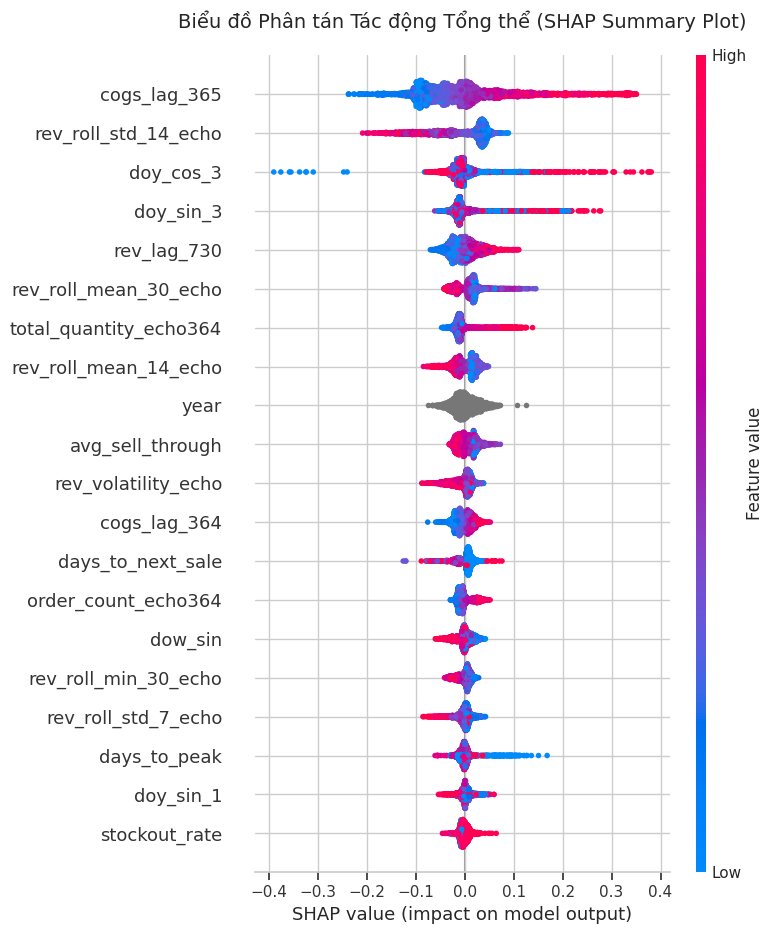

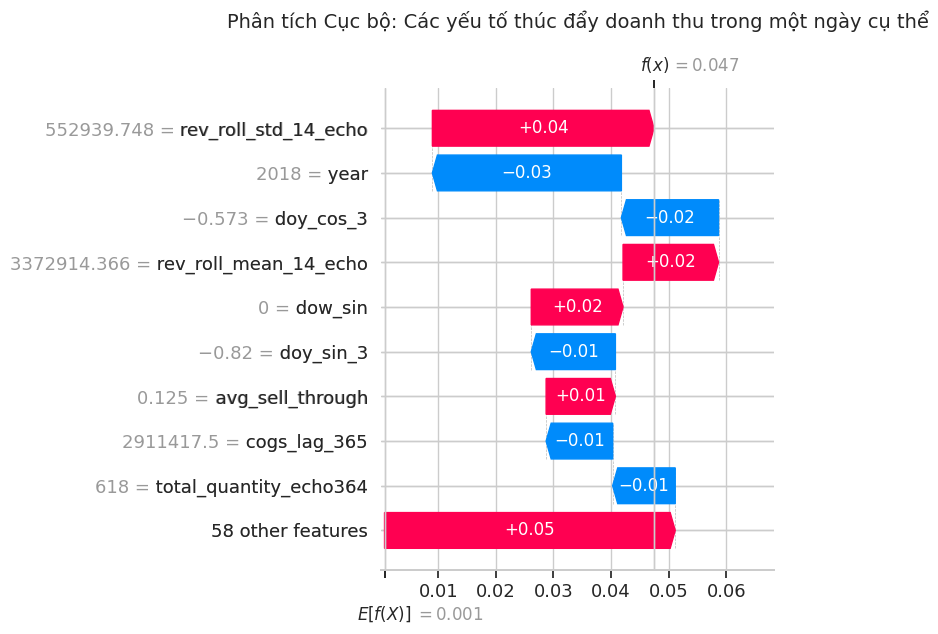


 Phân tích chuyên sâu từng đặc trưng


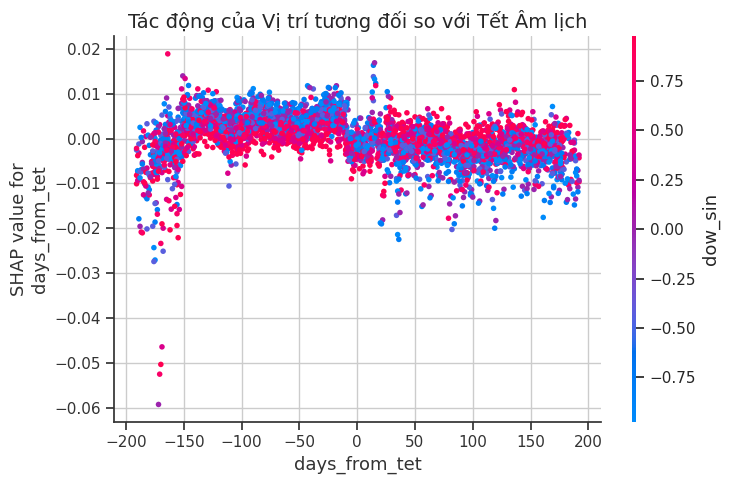

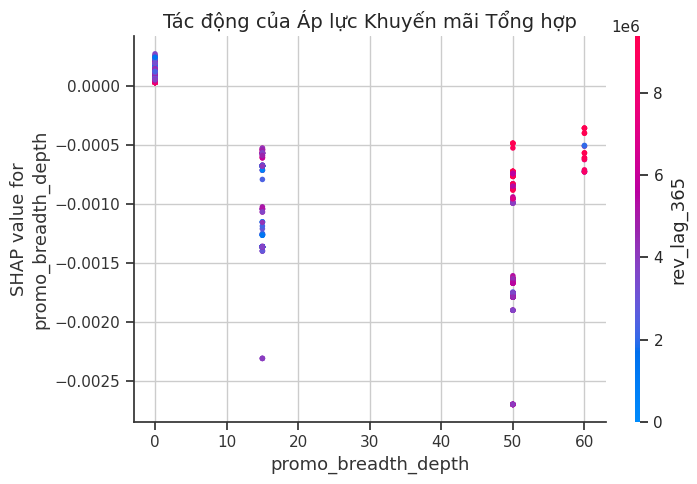


--- PHÂN TÍCH CHUYÊN SÂU TỪNG ĐẶC TRƯNG ---


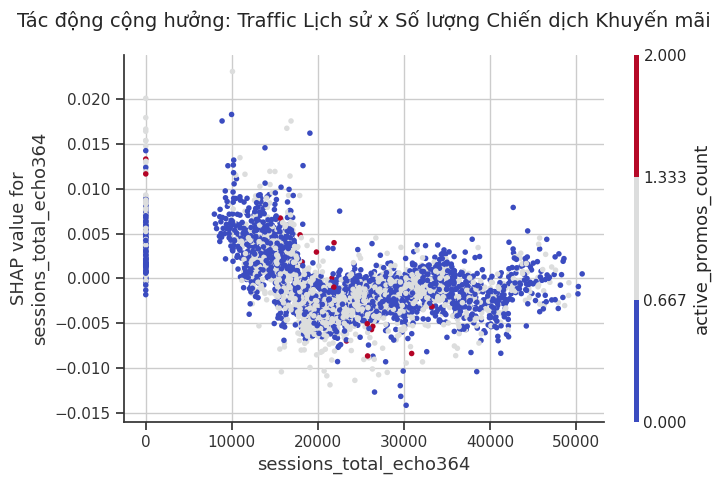

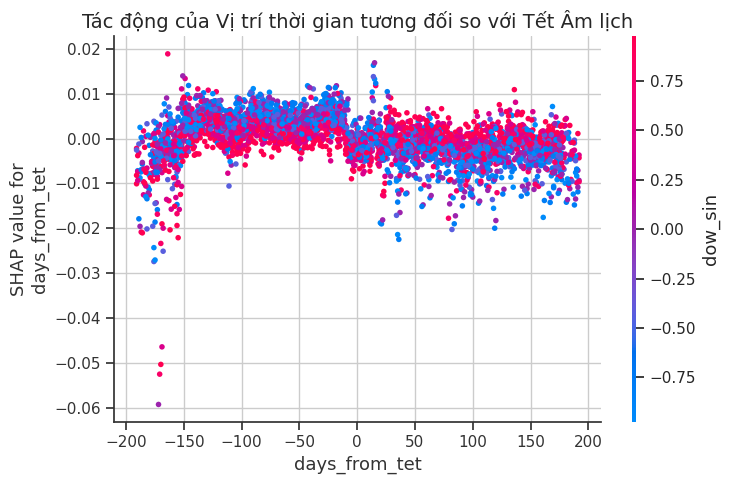

In [22]:
# CELL 19 - GIẢI THÍCH MÔ HÌNH VỚI SHAP

# Khai báo dữ liệu và mô hình từ Pipeline
# Lấy mẫu đại diện 
X_shap = X_train_full.sample(n=min(5000, len(X_train_full)), random_state=SEED)

print("Đang tính toán SHAP values")
explainer = shap.TreeExplainer(f_rev_xgb)
shap_values = explainer.shap_values(X_shap)
print("Tính toán hoàn tất! Đang xuất biểu đồ")

# Khai báo dữ liệu và explainer
# Sử dụng XGBoost là base-model mạnh nhất để giải thích.
X_shap = X_train_full.sample(n=min(5000, len(X_train_full)), random_state=SEED)

print("Đang tính toán SHAP values")
explainer = shap.TreeExplainer(f_rev_xgb)
shap_values = explainer.shap_values(X_shap)
shap_obj = explainer(X_shap) # Cần cho biểu đồ Waterfall
print("Đang xuất biểu đồ...")

# TÁC ĐỘNG TỔNG QUAN
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, show=False)
plt.title("Biểu đồ Phân tán Tác động Tổng thể (SHAP Summary Plot)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# WATERFALL PLOT CHO 1 NGÀY
idx_to_explain = 0 
plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_obj[idx_to_explain], max_display=10, show=False)
plt.title("Phân tích Cục bộ: Các yếu tố thúc đẩy doanh thu trong một ngày cụ thể", fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Phân tích Tương tác (Dependence Plot) 
# Chọn 2 biến đặc thù để xem sự thay đổi của doanh thu khi các biến này thay đổi
print("\n Phân tích chuyên sâu từng đặc trưng")
try:
    # Tác động của Khoảng cách đến ngày Lễ/Tết
    if 'days_from_tet' in X_shap.columns:
        shap.dependence_plot('days_from_tet', shap_values, X_shap, show=False)
        plt.title("Tác động của Vị trí tương đối so với Tết Âm lịch", fontsize=14)
        plt.tight_layout()
        plt.show()
        
    # Tác động của Áp lực Khuyến mãi (Biến Interaction)
    if 'promo_breadth_depth' in X_shap.columns: # Đã cập nhật thành biến mới mạnh hơn
        shap.dependence_plot('promo_breadth_depth', shap_values, X_shap, show=False)
        plt.title("Tác động của Áp lực Khuyến mãi Tổng hợp", fontsize=14)
        plt.tight_layout()
        plt.show()
except Exception as e:
    print(f"Bỏ qua Dependence Plot do thiếu biến hoặc lỗi: {e}")

# PHÂN TÍCH TƯƠNG TÁC KÉP TRONG E-COMMERCE
print("\n--- PHÂN TÍCH CHUYÊN SÂU TỪNG ĐẶC TRƯNG ---")
try:
    # 3.1 Sự cộng hưởng giữa Lưu lượng Traffic lịch sử và Mật độ Khuyến mãi
    if 'sessions_total_echo364' in X_shap.columns and 'active_promos_count' in X_shap.columns:
        shap.dependence_plot(
            'sessions_total_echo364', 
            shap_values, 
            X_shap, 
            interaction_index='active_promos_count',
            show=False,
            cmap=plt.get_cmap("coolwarm")
        )
        plt.title("Tác động cộng hưởng: Traffic Lịch sử x Số lượng Chiến dịch Khuyến mãi", fontsize=14, pad=20)
        plt.tight_layout()
        plt.show()
        
    # 3.2 Tác động của Tâm lý chờ đợi Lễ/Tết
    if 'days_from_tet' in X_shap.columns:
        shap.dependence_plot('days_from_tet', shap_values, X_shap, show=False)
        plt.title("Tác động của Vị trí thời gian tương đối so với Tết Âm lịch", fontsize=14)
        plt.tight_layout()
        plt.show()
        
except Exception as e:
    print(f"Bỏ qua Dependence Plot do cấu hình biến thay đổi: {e}")

In [23]:
# CELL 20 - XUẤT FILE

# Trích xuất đúng 3 cột yêu cầu
submission = test_df[['Date', 'Revenue', 'COGS']].copy()

# Lọc đúng giai đoạn theo yêu cầu
submission = submission[(submission['Date'] >= TEST_START) & (submission['Date'] <= TEST_END)]

# Đảm bảo Date là định dạng chuỗi YYYY-MM-DD chuẩn
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')

# Xuất file
submission_file_name = 'submission.csv'
submission.to_csv(submission_file_name, index=False)

print(f"Đã lưu kết quả tại: {submission_file_name}")
print(f"Số dòng xuất ra: {len(submission)}")
display(submission.head(10))

Đã lưu kết quả tại: submission.csv
Số dòng xuất ra: 548


,Date,Revenue,COGS
3833,2023-01-01,3171383.91,2654009.40
3834,2023-01-02,1491859.17,1238258.13
3835,2023-01-03,1408679.68,1172548.72
3836,2023-01-04,1521303.09,1267696.83
3837,2023-01-05,1077536.31,894179.41
3838,2023-01-06,1175377.09,977171.61
3839,2023-01-07,1666740.05,1394677.55
3840,2023-01-08,1960720.49,1634388.93
3841,2023-01-09,2067496.54,1722032.68
3842,2023-01-10,1888867.06,1564290.20
